### 第三次作業


In [17]:
import torch
import torchvision

print("torch version:", torch.__version__)
print("torchvision version:", torchvision.__version__)


torch version: 2.7.1+cu118
torchvision version: 0.22.1+cu118


### 2. 匯入套件


In [18]:
# === 基本套件 ===
import os
import time
import random
import numpy as np
import pandas as pd

# === PyTorch / TorchVision ===
import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader
from torchvision import datasets, transforms

# === TorchVision models（新版 weights 寫法）===
from torchvision.models import (
    resnet18, ResNet18_Weights,
    mobilenet_v2, MobileNet_V2_Weights,
    # vgg16, VGG16_Weights,                 # 可選：較耗 GPU
    # densenet121, DenseNet121_Weights      # 可選：較耗 GPU
)



# === 評估指標 ===
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support
)

# === 繪圖 ===
import matplotlib.pyplot as plt

import matplotlib as mpl
import matplotlib.pyplot as plt

# Windows 常見中文字型：微軟正黑體 / 新細明體
mpl.rcParams['font.family'] = ['Microsoft JhengHei']   # 或 'PMingLiU'
mpl.rcParams['axes.unicode_minus'] = False             # 解決負號顯示成方塊




### 3. 固定 random seed（確保可重現）


In [19]:
def set_seed(seed: int = 42):
    # 固定 Python、NumPy、PyTorch 的隨機性
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    # 讓 cudnn 更可重現（注意：可能略降速）
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

SEED = 42
set_seed(SEED)
print(f"已固定 random seed = {SEED}")


已固定 random seed = 42


### 4. CUDA GPU 檢查（自動偵測並使用 GPU 訓練）


In [20]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("目前使用裝置：", device)
if device.type == "cuda":
    print("GPU 名稱：", torch.cuda.get_device_name(0))
    print("GPU 數量：", torch.cuda.device_count())


目前使用裝置： cuda
GPU 名稱： NVIDIA GeForce RTX 3080
GPU 數量： 1


### 5. 路徑設定（本機資料夾結構）


In [21]:
# 依題目要求：DATA_ROOT = "."
DATA_ROOT = "."

train_dir = os.path.join(DATA_ROOT, "train")
valid_dir = os.path.join(DATA_ROOT, "valid")

print("Train 路徑：", train_dir)
print("Valid 路徑：", valid_dir)

assert os.path.isdir(train_dir), "找不到 train/ 資料夾，請確認 Notebook 與 train/ 同層"
assert os.path.isdir(valid_dir), "找不到 valid/ 資料夾，請確認 Notebook 與 valid/ 同層"


Train 路徑： .\train
Valid 路徑： .\valid


### 6. Transforms（train / valid 分開；ImageNet mean/std；可切換 img_size）


In [22]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
import torch

# ImageNet normalization（固定）
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]
NUM_WORKERS = 2

def build_transforms(img_size: int = 224, use_augmentation: bool = True):
    # --- Train transform ---
    if use_augmentation:
        train_tf = transforms.Compose([
            transforms.Resize((img_size, img_size)),
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomRotation(degrees=15),
            transforms.ToTensor(),
            transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
        ])
    else:
        train_tf = transforms.Compose([
            transforms.Resize((img_size, img_size)),
            transforms.ToTensor(),
            transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
        ])

    # --- Validation / Test transform ---
    valid_tf = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.ToTensor(),
        transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ])

    return train_tf, valid_tf


def build_dataloaders(
    img_size: int = 224,
    use_augmentation: bool = True,
    batch_size: int = 128,
    val_ratio: float = 0.2
):
    # === Transforms ===
    train_tf, valid_tf = build_transforms(img_size, use_augmentation)

    # === 各自建立 dataset（不要共用 ImageFolder）===
    train_dataset_full = datasets.ImageFolder(
        root=train_dir,
        transform=train_tf
    )

    val_dataset_full = datasets.ImageFolder(
        root=train_dir,
        transform=valid_tf
    )

    test_dataset = datasets.ImageFolder(
        root=valid_dir,
        transform=valid_tf
    )

    # === 固定切分（確保 train / val index 一致）===
    num_samples = len(train_dataset_full)
    indices = torch.randperm(num_samples, generator=torch.Generator().manual_seed(SEED))

    val_size = int(num_samples * val_ratio)
    val_indices = indices[:val_size]
    train_indices = indices[val_size:]

    train_dataset = Subset(train_dataset_full, train_indices)
    val_dataset   = Subset(val_dataset_full, val_indices)

    # === DataLoader（效能最佳化設定）===
    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=NUM_WORKERS,      # 建議 2（你是 4 核 CPU）
        pin_memory=True,
        persistent_workers=True
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=True,
        persistent_workers=True
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=True
    )

    return train_loader, val_loader, test_loader, train_dataset_full.classes


### 7. Dataset 與 DataLoader（ImageFolder 讀取 train / valid）


In [23]:
# 固定超參數（控制變因）
BATCH_SIZE = 128
NUM_WORKERS = 2  # Windows 若有問題可改 0
EPOCHS = 50
LR = 1e-4

from torch.utils.data import DataLoader, random_split

def build_dataloaders(
    img_size: int = 224,
    use_augmentation: bool = True,  # 這是外部傳入的參數
    batch_size: int = 128,
    val_ratio: float = 0.2
):
    # === Transforms ===
    # 修正點 1：這裡要用傳入的變數 use_augmentation，不要寫死 True
    train_tf, val_tf = build_transforms(img_size, use_augmentation=use_augmentation)
    _, test_tf = build_transforms(img_size, use_augmentation=False)

    # === 修正點 2：避免 random_split 的共用參照問題 ===
    # 方法：先建立一個 dataset 來取得切分索引，然後分別建立真正的 train 和 val dataset
    
    # 1. 先讀取一次資料，只為了取得長度與切分索引
    temp_dataset = datasets.ImageFolder(root=train_dir) 
    val_size = int(len(temp_dataset) * val_ratio)
    train_size = len(temp_dataset) - val_size
    
    # 取得切分的索引 (indices)
    train_subset, val_subset = random_split(
        temp_dataset, 
        [train_size, val_size],
        generator=torch.Generator().manual_seed(SEED)
    )
    
    train_idx = train_subset.indices
    val_idx = val_subset.indices

    # 2. 正式建立 Train Dataset (套用 train_tf)
    train_dataset_full = datasets.ImageFolder(root=train_dir, transform=train_tf)
    train_dataset = torch.utils.data.Subset(train_dataset_full, train_idx)

    # 3. 正式建立 Val Dataset (套用 val_tf)
    val_dataset_full = datasets.ImageFolder(root=train_dir, transform=val_tf)
    val_dataset = torch.utils.data.Subset(val_dataset_full, val_idx)

    # === test set ===
    test_dataset = datasets.ImageFolder(
        root=valid_dir,
        transform=test_tf
    )

    # === DataLoader ===
    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=NUM_WORKERS,
        pin_memory=True,
        persistent_workers=True
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=True,
        persistent_workers=True
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=True
    )

    return train_loader, val_loader, test_loader, train_dataset_full.classes
train_loader, val_loader, test_loader, class_names = build_dataloaders(
    img_size=224,
    use_augmentation=True,
    batch_size=BATCH_SIZE
)

print("train batches：", len(train_loader))
print("val batches：", len(val_loader))
print("test batches：", len(test_loader))


train batches： 10
val batches： 3
test batches： 4


### 8. 類別名稱與 class_to_idx


In [24]:
# 類別名稱
print("類別名稱（classes）：", class_names)

# class_to_idx（從 test_dataset 或 train_dataset 的 dataset 物件取都可以）
class_to_idx = test_loader.dataset.class_to_idx
num_classes = len(class_names)

print("class_to_idx：", class_to_idx)
print("num_classes：", num_classes)


類別名稱（classes）： ['amd', 'cataract', 'diabetes', 'normal']
class_to_idx： {'amd': 0, 'cataract': 1, 'diabetes': 2, 'normal': 3}
num_classes： 4


### 9. 模型定義（SimpleCNN / ResNet18 / MobileNetV2）


In [39]:
from torchvision.models import DenseNet121_Weights, densenet121

import torch
import torch.nn as nn

class SimpleCNN(nn.Module):
    def __init__(self, num_classes: int):
        super().__init__()
        # 增加層數與通道數，以解決實驗報告中提到的欠擬合問題
        self.features = nn.Sequential(
            # 第一段：擷取初步邊緣與色彩特徵
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),  # 224 -> 112

            # 第二段：增加寬度至 64 通道
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),  # 112 -> 56

            # 第三段：增加寬度至 128 通道
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),  # 56 -> 28

            # 第四段（新增）：更深層的特徵提取，增加至 256 通道
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),  # 28 -> 14
        )
        
        # 保留現代 CNN 的全域平均池化技巧
        self.gap = nn.AdaptiveAvgPool2d((1, 1)) # 強制壓縮成 256 * 1 * 1 [cite: 224]
        
        self.classifier = nn.Sequential(
            nn.Flatten(),
            # 增加全連接層的維度，以匹配新增的卷積層輸出
            nn.Linear(256, 256), 
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.4), # 略微提高 Dropout 以防過擬合
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.gap(x)
        x = self.classifier(x)
        return x

def get_model(model_name: str, num_classes: int, freeze_backbone: bool = False):
    model_name = model_name.lower()

    if model_name == "simplecnn":
        model = SimpleCNN(num_classes=num_classes)

    elif model_name == "resnet18":
        weights = ResNet18_Weights.DEFAULT
        model = resnet18(weights=weights)
        in_features = model.fc.in_features
        model.fc = nn.Linear(in_features, num_classes)

        # Freeze backbone：只訓練最後 fc
        if freeze_backbone:
            for p in model.parameters():
                p.requires_grad = False
            for p in model.fc.parameters():
                p.requires_grad = True

    elif model_name == "mobilenetv2":
        weights = MobileNet_V2_Weights.DEFAULT
        model = mobilenet_v2(weights=weights)
        in_features = model.classifier[1].in_features
        model.classifier[1] = nn.Linear(in_features, num_classes)

        # Freeze backbone：只訓練最後 classifier
        if freeze_backbone:
            for p in model.parameters():
                p.requires_grad = False
            for p in model.classifier.parameters():
                p.requires_grad = True

    # 可選：較耗 GPU（需要就自行取消註解）
    # elif model_name == "vgg16":
    #     weights = VGG16_Weights.DEFAULT
    #     model = vgg16(weights=weights)
    #     in_features = model.classifier[6].in_features
    #     model.classifier[6] = nn.Linear(in_features, num_classes)
    #     if freeze_backbone:
    #         for p in model.features.parameters():
    #             p.requires_grad = False

    # elif model_name == "densenet121":
    #     weights = DenseNet121_Weights.DEFAULT
    #     model = densenet121(weights=weights)
    #     in_features = model.classifier.in_features
    #     model.classifier = nn.Linear(in_features, num_classes)
    #     if freeze_backbone:
    #         for p in model.features.parameters():
    #             p.requires_grad = False

    else:
        raise ValueError(f"不支援的 model_name：{model_name}")

    return model


# 快速檢查模型是否可建
tmp = get_model("resnet18", num_classes=num_classes, freeze_backbone=True).to(device)
print("模型建立成功：ResNet18（freeze_backbone=True）")
del tmp
torch.cuda.empty_cache() if device.type == "cuda" else None


模型建立成功：ResNet18（freeze_backbone=True）


### 10. Freeze / Fine-tune 切換（參數可訓練數量檢查）


In [26]:
def count_trainable_params(model: nn.Module):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable

m_freeze = get_model("resnet18", num_classes, freeze_backbone=True)
m_finetune = get_model("resnet18", num_classes, freeze_backbone=False)

t1, tr1 = count_trainable_params(m_freeze)
t2, tr2 = count_trainable_params(m_finetune)

print(f"ResNet18 Freeze：總參數={t1:,}，可訓練={tr1:,}")
print(f"ResNet18 Fine-tune：總參數={t2:,}，可訓練={tr2:,}")


ResNet18 Freeze：總參數=11,178,564，可訓練=2,052
ResNet18 Fine-tune：總參數=11,178,564，可訓練=11,178,564


### 11. 訓練函式（固定：CrossEntropyLoss + Adam；輸出 Loss/Acc/時間）


In [27]:
def train_one_experiment(
    model_name: str,
    img_size: int = 224,
    use_augmentation: bool = True,
    freeze_backbone: bool = False,
    epochs: int = EPOCHS,
    lr: float = LR,
    batch_size: int = BATCH_SIZE
):
    set_seed(SEED)

    # === 正確取得 loader 與 class_names ===
    train_loader, val_loader, test_loader, class_names = build_dataloaders(
        img_size=img_size,
        use_augmentation=use_augmentation,
        batch_size=batch_size
    )

    num_classes = len(class_names)

    # === 建立模型 ===
    model = get_model(
        model_name,
        num_classes=num_classes,
        freeze_backbone=freeze_backbone
    ).to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr
    )

    history = {
        "train_loss": [], "train_acc": [],
        "val_loss": [], "val_acc": [],
    }

    # === Early Stopping 參數 ===
    patience = 10
    min_delta = 1e-4
    best_val_loss = float("inf")
    early_stop_counter = 0

    best_val_acc = -1.0
    best_state = None

    start_time = time.time()

    for epoch in range(1, epochs + 1):

        # -------- Training --------
        model.train()
        running_loss, correct, total = 0.0, 0, 0

        for images, labels in train_loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

        train_loss = running_loss / total
        train_acc = correct / total

        # -------- Validation --------
        model.eval()
        running_loss, correct, total = 0.0, 0, 0

        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(device, non_blocking=True)
                labels = labels.to(device, non_blocking=True)

                outputs = model(images)
                loss = criterion(outputs, labels)

                running_loss += loss.item() * images.size(0)
                preds = outputs.argmax(dim=1)
                correct += (preds == labels).sum().item()
                total += labels.size(0)

        val_loss = running_loss / total
        val_acc = correct / total

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        # === Early Stopping（依 val loss）===
        if best_val_loss - val_loss > min_delta:
            best_val_loss = val_loss
            best_val_acc = val_acc  # <--- 確保這兩個是同步的
            early_stop_counter = 0
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        else:
            early_stop_counter += 1

        if val_acc > best_val_acc:
            best_val_acc = val_acc

        print(
            f"[{model_name}] Epoch {epoch:03d}/{epochs} | "
            f"Train Loss {train_loss:.4f} Acc {train_acc:.4f} | "
            f"Val Loss {val_loss:.4f} Acc {val_acc:.4f}"
        )

        if early_stop_counter >= patience:
            print(f"⛔ Early stopping triggered at epoch {epoch}")
            break

    train_time_sec = time.time() - start_time

    # 載回最佳權重（validation loss 最低）
    if best_state is not None:
        model.load_state_dict(best_state)

    result = {
    "model_name": model_name,
    "img_size": img_size,
    "use_augmentation": use_augmentation,
    "freeze_backbone": freeze_backbone,
    "epochs_run": len(history["train_loss"]),  # 實際跑了幾個 epoch
    "batch_size": batch_size,
    "lr": lr,
    "best_val_acc": best_val_acc,          # ✅ 修正這行
    "best_val_loss": best_val_loss,
    "train_time_sec": train_time_sec,
    "history": history,
    "model": model,
    "class_names": class_names,
    "test_loader": test_loader              # 如果你後面 run_and_report 會用
}


    return result


### 12. 評估函式（Accuracy、Precision/Recall/F1 per-class + macro、classification_report）


In [28]:
def evaluate_model(model: nn.Module, data_loader: DataLoader, class_names):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in data_loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            outputs = model(images)
            preds = outputs.argmax(dim=1)

            all_preds.append(preds.cpu().numpy())
            all_labels.append(labels.cpu().numpy())

    y_pred = np.concatenate(all_preds)
    y_true = np.concatenate(all_labels)

    # Accuracy
    acc = (y_pred == y_true).mean()

    # per-class / macro 指標
    precision, recall, f1, support = precision_recall_fscore_support(
        y_true, y_pred, labels=list(range(len(class_names))), zero_division=0
    )
    macro_p, macro_r, macro_f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0
    )

    report = classification_report(
        y_true, y_pred, target_names=class_names, digits=4, zero_division=0
    )

    metrics = {
        "acc": acc,
        "precision_per_class": precision,
        "recall_per_class": recall,
        "f1_per_class": f1,
        "support_per_class": support,
        "precision_macro": macro_p,
        "recall_macro": macro_r,
        "f1_macro": macro_f1,
        "classification_report": report,
        "y_true": y_true,
        "y_pred": y_pred,
    }
    return metrics


### 13. Confusion matrix 視覺化（含類別名稱）


In [29]:
def plot_confusion_matrix(y_true, y_pred, class_names, title="Confusion Matrix"):
    cm = confusion_matrix(y_true, y_pred, labels=list(range(len(class_names))))

    plt.figure(figsize=(7, 6))
    plt.imshow(cm, interpolation="nearest", cmap="Blues")
    plt.title(title)
    plt.colorbar()

    tick_marks = np.arange(len(class_names))
    plt.xticks(tick_marks, class_names, rotation=45, ha="right")
    plt.yticks(tick_marks, class_names)

    # 在格子上標數字
    thresh = cm.max() * 0.6 if cm.max() > 0 else 0.0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            val = cm[i, j]
            plt.text(j, i, str(val),
                     ha="center", va="center",
                     color="white" if val > thresh else "black")

    plt.ylabel("True Label")
    plt.xlabel("Predicted Label")
    plt.tight_layout()
    plt.show()


### 14. Loss / Accuracy 曲線（每個實驗皆畫）


In [30]:
def plot_curves(history, title_prefix=""):
    epochs = list(range(1, len(history["train_loss"]) + 1))

    # Loss curve
    plt.figure(figsize=(7, 4))
    plt.plot(epochs, history["train_loss"], label="Train Loss")
    plt.plot(epochs, history["val_loss"], label="Valid Loss")
    plt.title(f"{title_prefix} Loss Curve")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Accuracy curve
    plt.figure(figsize=(7, 4))
    plt.plot(epochs, history["train_acc"], label="Train Acc")
    plt.plot(epochs, history["val_acc"], label="Valid Acc")
    plt.title(f"{title_prefix} Accuracy Curve")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.tight_layout()
    plt.show()


### 15. 單次實驗執行與輸出（統一格式：曲線 + report + confusion matrix）


In [31]:
def run_and_report(
    exp_name: str,
    model_name: str,
    img_size: int = 224,
    use_augmentation: bool = True,
    freeze_backbone: bool = False
):
    print("=" * 90)
    print(f"實驗：{exp_name}")
    print(f"model={model_name} | img_size={img_size} | aug={use_augmentation} | freeze={freeze_backbone}")
    print("=" * 90)

    # === 訓練（內含 early stopping，使用 train/val）===
    result = train_one_experiment(
        model_name=model_name,
        img_size=img_size,
        use_augmentation=use_augmentation,
        freeze_backbone=freeze_backbone,
        epochs=EPOCHS,
        lr=LR,
        batch_size=BATCH_SIZE
    )

    model = result["model"]
    history = result["history"]
    class_names = result["class_names"]
    test_loader = result["test_loader"]

    # === Loss / Accuracy 曲線 ===
    plot_curves(history, title_prefix=f"{exp_name} | {model_name}")

    # === Test set 評估（只用 test_loader）===
    metrics = evaluate_model(model, test_loader, class_names)

    print("---- classification_report (Test set) ----")
    print(metrics["classification_report"])

    # per-class 指標表
    per_class_df = pd.DataFrame({
        "class": class_names,
        "precision": metrics["precision_per_class"],
        "recall": metrics["recall_per_class"],
        "f1": metrics["f1_per_class"],
        "support": metrics["support_per_class"],
    })
    display(per_class_df)

    # macro metrics
    summary = {
        "exp_name": exp_name,
        "model": model_name,
        "img_size": img_size,
        "augmentation": use_augmentation,
        "freeze": freeze_backbone,
        "acc": metrics["acc"],
        "precision_macro": metrics["precision_macro"],
        "recall_macro": metrics["recall_macro"],
        "f1_macro": metrics["f1_macro"],
        "epochs_run": result["epochs_run"],
        "train_time_sec": result["train_time_sec"],
    }

    # confusion matrix（Test set）
    plot_confusion_matrix(
        metrics["y_true"],
        metrics["y_pred"],
        class_names,
        title=f"{exp_name} | {model_name} (Test set)"
    )

    return summary


### 16. 實驗一：不同 CNN 模型比較（img_size=224；train 有 augmentation）


實驗：實驗一-1 不同模型比較
model=simplecnn | img_size=224 | aug=False | freeze=False
[simplecnn] Epoch 001/50 | Train Loss 1.3500 Acc 0.3127 | Val Loss 1.3782 Acc 0.3396
[simplecnn] Epoch 002/50 | Train Loss 1.2692 Acc 0.4592 | Val Loss 1.3414 Acc 0.3679
[simplecnn] Epoch 003/50 | Train Loss 1.2183 Acc 0.5157 | Val Loss 1.2615 Acc 0.5472
[simplecnn] Epoch 004/50 | Train Loss 1.1754 Acc 0.5345 | Val Loss 1.1744 Acc 0.5566
[simplecnn] Epoch 005/50 | Train Loss 1.1315 Acc 0.5478 | Val Loss 1.1164 Acc 0.5566
[simplecnn] Epoch 006/50 | Train Loss 1.1028 Acc 0.5564 | Val Loss 1.0756 Acc 0.5629
[simplecnn] Epoch 007/50 | Train Loss 1.0643 Acc 0.5792 | Val Loss 1.0418 Acc 0.5912
[simplecnn] Epoch 008/50 | Train Loss 1.0267 Acc 0.5948 | Val Loss 1.0058 Acc 0.6038
[simplecnn] Epoch 009/50 | Train Loss 0.9997 Acc 0.6011 | Val Loss 0.9807 Acc 0.6164
[simplecnn] Epoch 010/50 | Train Loss 0.9661 Acc 0.6168 | Val Loss 0.9550 Acc 0.6132
[simplecnn] Epoch 011/50 | Train Loss 0.9470 Acc 0.6136 | Val Loss 0.9264 Ac

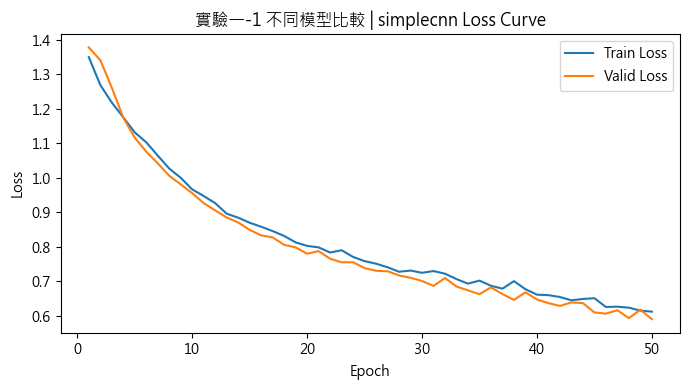

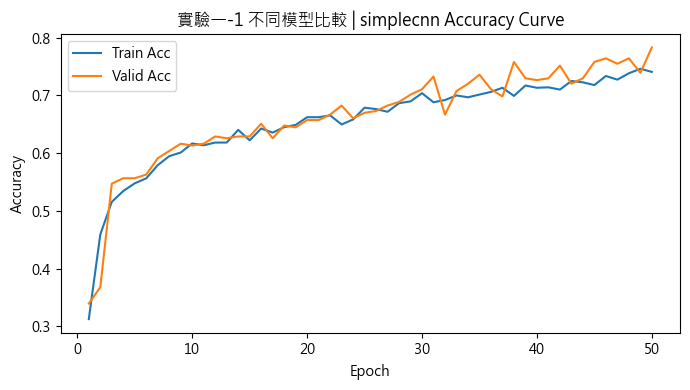

---- classification_report (Test set) ----
              precision    recall  f1-score   support

         amd     0.7308    0.5700    0.6404       100
    cataract     0.9245    0.9800    0.9515       100
    diabetes     0.5294    0.5400    0.5347       100
      normal     0.7105    0.8100    0.7570       100

    accuracy                         0.7250       400
   macro avg     0.7238    0.7250    0.7209       400
weighted avg     0.7238    0.7250    0.7209       400



,class,precision,recall,f1,support
0,amd,0.730769,0.57,0.640449,100
1,cataract,0.924528,0.98,0.951456,100
2,diabetes,0.529412,0.54,0.534653,100
3,normal,0.710526,0.81,0.757009,100


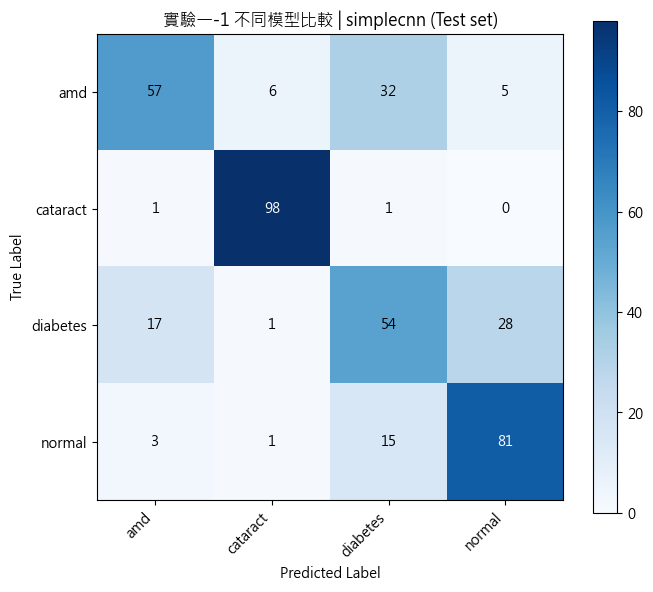

實驗：實驗一-2 不同模型比較
model=resnet18 | img_size=224 | aug=False | freeze=False
[resnet18] Epoch 001/50 | Train Loss 0.7153 Acc 0.7241 | Val Loss 0.4997 Acc 0.8333
[resnet18] Epoch 002/50 | Train Loss 0.2055 Acc 0.9373 | Val Loss 0.3377 Acc 0.8994
[resnet18] Epoch 003/50 | Train Loss 0.0793 Acc 0.9796 | Val Loss 0.2771 Acc 0.8931
[resnet18] Epoch 004/50 | Train Loss 0.0233 Acc 1.0000 | Val Loss 0.2762 Acc 0.9057
[resnet18] Epoch 005/50 | Train Loss 0.0105 Acc 1.0000 | Val Loss 0.2733 Acc 0.9151
[resnet18] Epoch 006/50 | Train Loss 0.0072 Acc 1.0000 | Val Loss 0.2461 Acc 0.8994
[resnet18] Epoch 007/50 | Train Loss 0.0043 Acc 1.0000 | Val Loss 0.2434 Acc 0.9119
[resnet18] Epoch 008/50 | Train Loss 0.0036 Acc 1.0000 | Val Loss 0.2505 Acc 0.9119
[resnet18] Epoch 009/50 | Train Loss 0.0023 Acc 1.0000 | Val Loss 0.2550 Acc 0.9119
[resnet18] Epoch 010/50 | Train Loss 0.0025 Acc 1.0000 | Val Loss 0.2500 Acc 0.9119
[resnet18] Epoch 011/50 | Train Loss 0.0021 Acc 1.0000 | Val Loss 0.2520 Acc 0.9088
[re

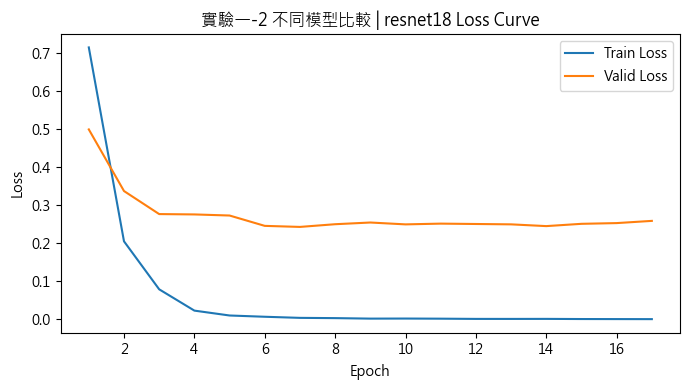

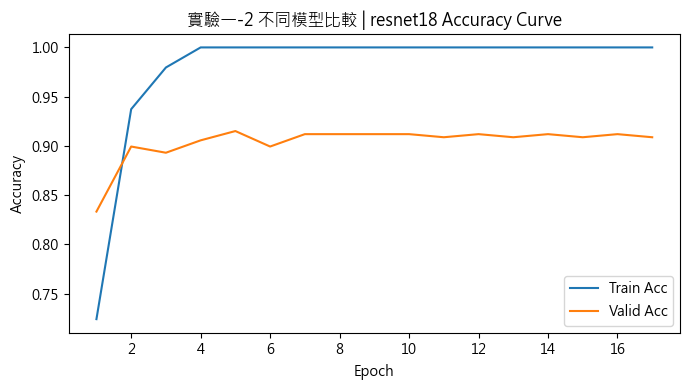

---- classification_report (Test set) ----
              precision    recall  f1-score   support

         amd     0.9429    0.9900    0.9659       100
    cataract     1.0000    0.9900    0.9950       100
    diabetes     0.9368    0.8900    0.9128       100
      normal     0.9208    0.9300    0.9254       100

    accuracy                         0.9500       400
   macro avg     0.9501    0.9500    0.9498       400
weighted avg     0.9501    0.9500    0.9498       400



,class,precision,recall,f1,support
0,amd,0.942857,0.99,0.965854,100
1,cataract,1.000000,0.99,0.994975,100
2,diabetes,0.936842,0.89,0.912821,100
3,normal,0.920792,0.93,0.925373,100


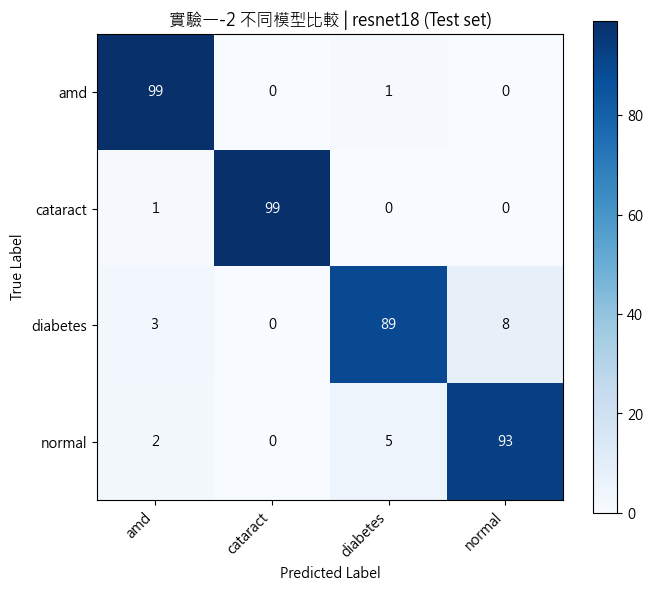

=== 實驗一結果表 ===


,exp_name,model,img_size,augmentation,freeze,acc,precision_macro,recall_macro,f1_macro,epochs_run,train_time_sec
1,實驗一-2 不同模型比較,resnet18,224,False,False,0.950,0.950123,0.950,0.949756,17,402.942512
0,實驗一-1 不同模型比較,simplecnn,224,False,False,0.725,0.723809,0.725,0.720892,50,1183.177518


In [32]:
exp1_summaries = []

# 依題目：SimpleCNN / ResNet18(pretrained) / MobileNetV2(pretrained)
exp1_summaries.append(run_and_report(
    exp_name="實驗一-1 不同模型比較",
    model_name="simplecnn",
    img_size=224,
    use_augmentation=False,
    freeze_backbone=False
))

exp1_summaries.append(run_and_report(
    exp_name="實驗一-2 不同模型比較",
    model_name="resnet18",
    img_size=224,
    use_augmentation=False,
    freeze_backbone=False
))

# exp1_summaries.append(run_and_report(
#     exp_name="實驗一-3 不同模型比較",
#     model_name="mobilenetv2",
#     img_size=224,
#     use_augmentation=False,
#     freeze_backbone=False
# ))

exp1_df = pd.DataFrame(exp1_summaries)
print("=== 實驗一結果表 ===")
display(exp1_df.sort_values(by="acc", ascending=False))


實驗：實驗一-3 不同模型比較
model=mobilenetv2 | img_size=224 | aug=False | freeze=False
[mobilenetv2] Epoch 001/50 | Train Loss 1.2078 Acc 0.5596 | Val Loss 1.0744 Acc 0.5849
[mobilenetv2] Epoch 002/50 | Train Loss 0.8529 Acc 0.7908 | Val Loss 0.7393 Acc 0.7484
[mobilenetv2] Epoch 003/50 | Train Loss 0.6046 Acc 0.8605 | Val Loss 0.5611 Acc 0.7987
[mobilenetv2] Epoch 004/50 | Train Loss 0.4258 Acc 0.8942 | Val Loss 0.4364 Acc 0.8648
[mobilenetv2] Epoch 005/50 | Train Loss 0.3046 Acc 0.9114 | Val Loss 0.3509 Acc 0.8774
[mobilenetv2] Epoch 006/50 | Train Loss 0.2037 Acc 0.9530 | Val Loss 0.2967 Acc 0.8931
[mobilenetv2] Epoch 007/50 | Train Loss 0.1436 Acc 0.9694 | Val Loss 0.2760 Acc 0.8931
[mobilenetv2] Epoch 008/50 | Train Loss 0.0941 Acc 0.9875 | Val Loss 0.2527 Acc 0.9119
[mobilenetv2] Epoch 009/50 | Train Loss 0.0607 Acc 0.9953 | Val Loss 0.2476 Acc 0.9088
[mobilenetv2] Epoch 010/50 | Train Loss 0.0408 Acc 0.9945 | Val Loss 0.2501 Acc 0.9119
[mobilenetv2] Epoch 011/50 | Train Loss 0.0272 Acc 0.9

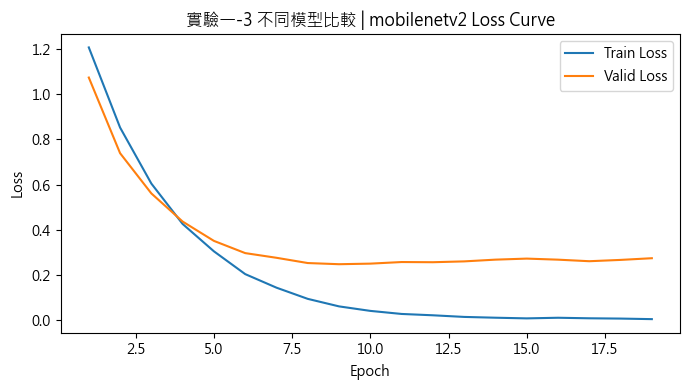

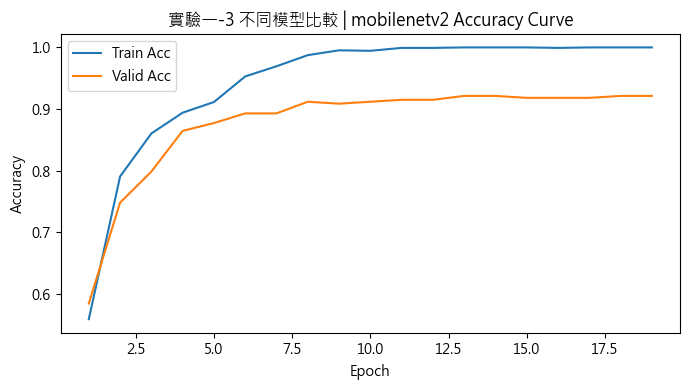

---- classification_report (Test set) ----
              precision    recall  f1-score   support

         amd     0.9600    0.9600    0.9600       100
    cataract     0.9901    1.0000    0.9950       100
    diabetes     0.9239    0.8500    0.8854       100
      normal     0.8879    0.9500    0.9179       100

    accuracy                         0.9400       400
   macro avg     0.9405    0.9400    0.9396       400
weighted avg     0.9405    0.9400    0.9396       400



,class,precision,recall,f1,support
0,amd,0.960000,0.96,0.960000,100
1,cataract,0.990099,1.00,0.995025,100
2,diabetes,0.923913,0.85,0.885417,100
3,normal,0.887850,0.95,0.917874,100


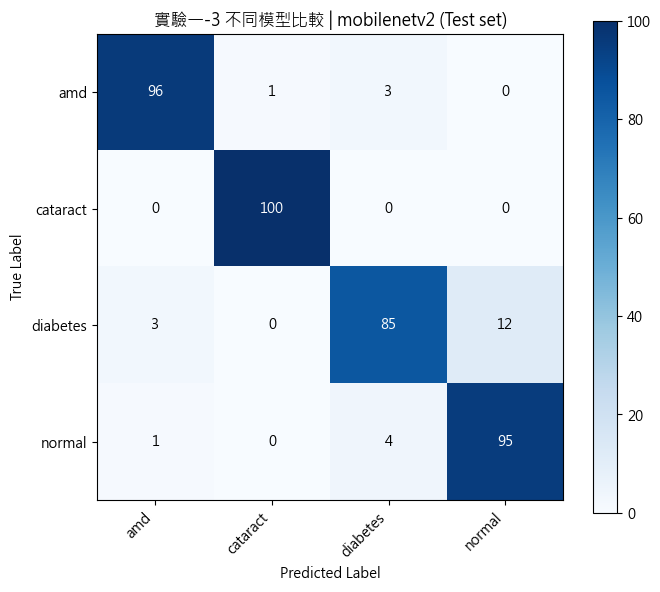

=== 實驗一結果表 ===


,exp_name,model,img_size,augmentation,freeze,acc,precision_macro,recall_macro,f1_macro,epochs_run,train_time_sec
1,實驗一-2 不同模型比較,resnet18,224,False,False,0.950,0.950123,0.950,0.949756,17,402.942512
2,實驗一-3 不同模型比較,mobilenetv2,224,False,False,0.940,0.940466,0.940,0.939579,19,5216.976905
0,實驗一-1 不同模型比較,simplecnn,224,False,False,0.725,0.723809,0.725,0.720892,50,1183.177518


In [38]:
exp1_summaries.append(run_and_report(
    exp_name="實驗一-3 不同模型比較",
    model_name="mobilenetv2",
    img_size=224,
    use_augmentation=False,
    freeze_backbone=False
)) 
exp1_df = pd.DataFrame(exp1_summaries)
print("=== 實驗一結果表 ===")
display(exp1_df.sort_values(by="acc", ascending=False))

實驗：實驗一-1 不同模型比較
model=simplecnn | img_size=224 | aug=False | freeze=False
[simplecnn] Epoch 001/50 | Train Loss 1.3135 Acc 0.3542 | Val Loss 1.3800 Acc 0.3302
[simplecnn] Epoch 002/50 | Train Loss 1.1644 Acc 0.5298 | Val Loss 1.3538 Acc 0.2642
[simplecnn] Epoch 003/50 | Train Loss 1.0581 Acc 0.5854 | Val Loss 1.2324 Acc 0.3836
[simplecnn] Epoch 004/50 | Train Loss 0.9802 Acc 0.6034 | Val Loss 1.0315 Acc 0.5535
[simplecnn] Epoch 005/50 | Train Loss 0.9114 Acc 0.6223 | Val Loss 0.9144 Acc 0.6164
[simplecnn] Epoch 006/50 | Train Loss 0.8694 Acc 0.6395 | Val Loss 0.8567 Acc 0.6321
[simplecnn] Epoch 007/50 | Train Loss 0.8361 Acc 0.6536 | Val Loss 0.8219 Acc 0.6352
[simplecnn] Epoch 008/50 | Train Loss 0.8024 Acc 0.6599 | Val Loss 0.7870 Acc 0.6258
[simplecnn] Epoch 009/50 | Train Loss 0.7792 Acc 0.6614 | Val Loss 0.7603 Acc 0.6572
[simplecnn] Epoch 010/50 | Train Loss 0.7490 Acc 0.6763 | Val Loss 0.7424 Acc 0.6509
[simplecnn] Epoch 011/50 | Train Loss 0.7512 Acc 0.6850 | Val Loss 0.7341 Ac

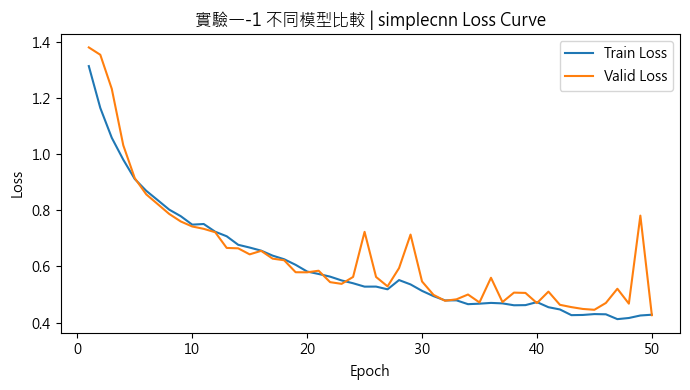

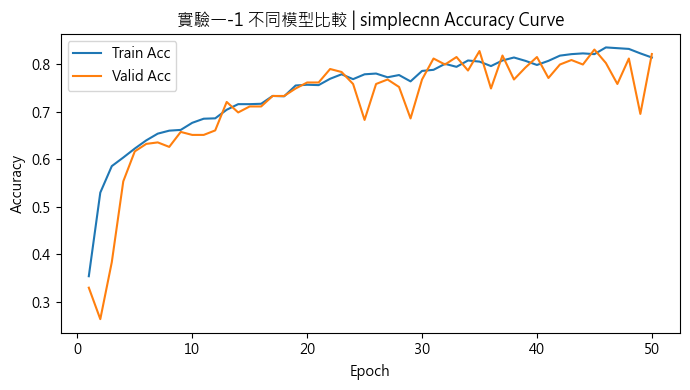

---- classification_report (Test set) ----
              precision    recall  f1-score   support

         amd     0.7684    0.7300    0.7487       100
    cataract     0.9600    0.9600    0.9600       100
    diabetes     0.7356    0.6400    0.6845       100
      normal     0.7712    0.9100    0.8349       100

    accuracy                         0.8100       400
   macro avg     0.8088    0.8100    0.8070       400
weighted avg     0.8088    0.8100    0.8070       400



,class,precision,recall,f1,support
0,amd,0.768421,0.73,0.748718,100
1,cataract,0.960000,0.96,0.960000,100
2,diabetes,0.735632,0.64,0.684492,100
3,normal,0.771186,0.91,0.834862,100


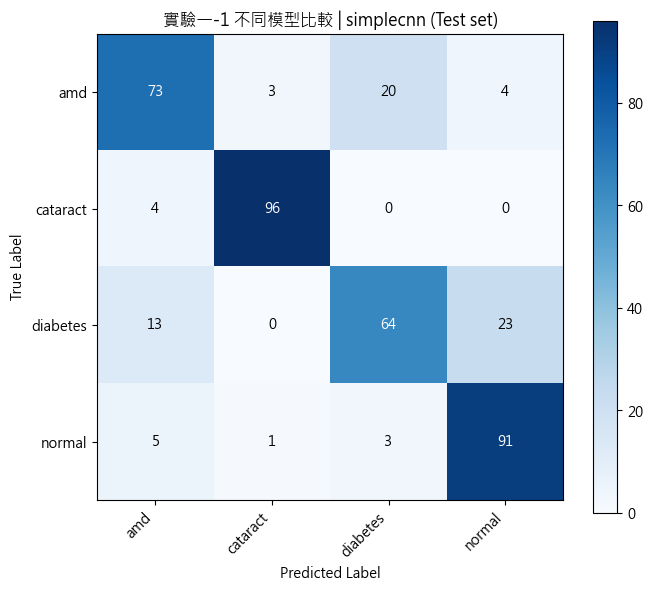

In [40]:
exp1_summaries.append(run_and_report(
    exp_name="實驗一-1 不同模型比較",
    model_name="simplecnn",
    img_size=224,
    use_augmentation=False,
    freeze_backbone=False
))

### 17. 實驗二：不同輸入尺寸（mobilenetv2 pretrained；比較 img_size=128/224/256）


實驗：實驗二 ResNet18 不同輸入尺寸（img_size=128）
model=resnet18 | img_size=128 | aug=False | freeze=False


[resnet18] Epoch 001/50 | Train Loss 0.7764 Acc 0.6904 | Val Loss 0.5807 Acc 0.7987
[resnet18] Epoch 002/50 | Train Loss 0.1936 Acc 0.9397 | Val Loss 0.4366 Acc 0.8553
[resnet18] Epoch 003/50 | Train Loss 0.0683 Acc 0.9890 | Val Loss 0.4053 Acc 0.8899
[resnet18] Epoch 004/50 | Train Loss 0.0223 Acc 0.9992 | Val Loss 0.4123 Acc 0.8805
[resnet18] Epoch 005/50 | Train Loss 0.0084 Acc 1.0000 | Val Loss 0.4093 Acc 0.8868
[resnet18] Epoch 006/50 | Train Loss 0.0058 Acc 1.0000 | Val Loss 0.4143 Acc 0.8868
[resnet18] Epoch 007/50 | Train Loss 0.0038 Acc 1.0000 | Val Loss 0.4145 Acc 0.8899
[resnet18] Epoch 008/50 | Train Loss 0.0033 Acc 1.0000 | Val Loss 0.4122 Acc 0.8931
[resnet18] Epoch 009/50 | Train Loss 0.0021 Acc 1.0000 | Val Loss 0.4156 Acc 0.8836
[resnet18] Epoch 010/50 | Train Loss 0.0023 Acc 1.0000 | Val Loss 0.4166 Acc 0.8868
[resnet18] Epoch 011/50 | Train Loss 0.0020 Acc 1.0000 | Val Loss 0.4212 Acc 0.8868
[resnet18] Epoch 012/50 | Train Loss 0.0014 Acc 1.0000 | Val Loss 0.4250 Acc

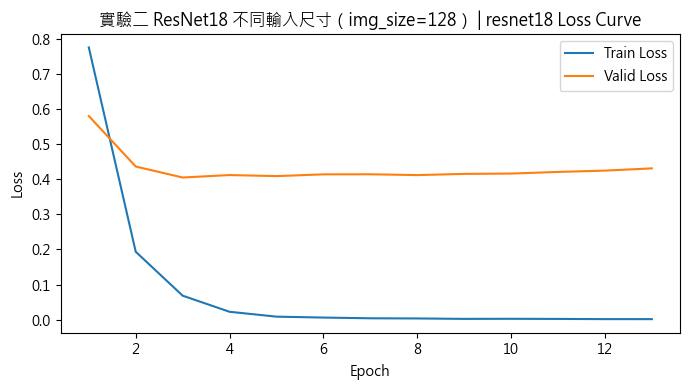

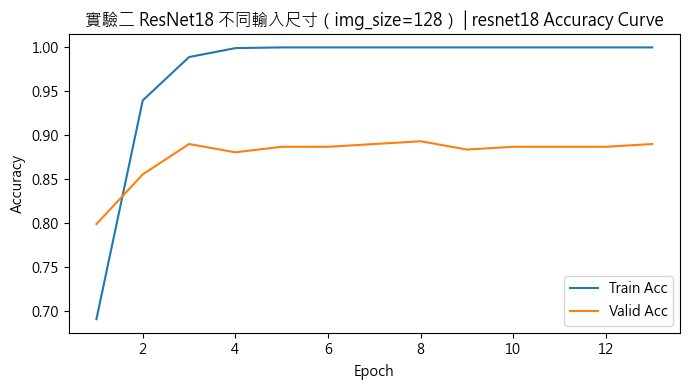

---- classification_report (Test set) ----
              precision    recall  f1-score   support

         amd     0.8962    0.9500    0.9223       100
    cataract     0.9800    0.9800    0.9800       100
    diabetes     0.9324    0.6900    0.7931       100
      normal     0.8083    0.9700    0.8818       100

    accuracy                         0.8975       400
   macro avg     0.9042    0.8975    0.8943       400
weighted avg     0.9042    0.8975    0.8943       400



,class,precision,recall,f1,support
0,amd,0.896226,0.95,0.922330,100
1,cataract,0.980000,0.98,0.980000,100
2,diabetes,0.932432,0.69,0.793103,100
3,normal,0.808333,0.97,0.881818,100


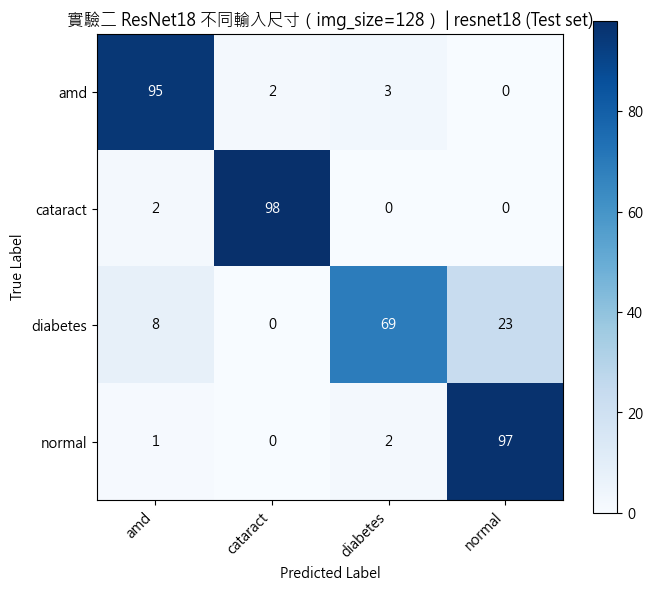

實驗：實驗二 ResNet18 不同輸入尺寸（img_size=256）
model=resnet18 | img_size=256 | aug=False | freeze=False
[resnet18] Epoch 001/50 | Train Loss 0.7096 Acc 0.7218 | Val Loss 0.5009 Acc 0.8239
[resnet18] Epoch 002/50 | Train Loss 0.2098 Acc 0.9326 | Val Loss 0.2996 Acc 0.9182
[resnet18] Epoch 003/50 | Train Loss 0.0889 Acc 0.9710 | Val Loss 0.2371 Acc 0.9214
[resnet18] Epoch 004/50 | Train Loss 0.0251 Acc 1.0000 | Val Loss 0.2228 Acc 0.9182
[resnet18] Epoch 005/50 | Train Loss 0.0115 Acc 1.0000 | Val Loss 0.2517 Acc 0.9151
[resnet18] Epoch 006/50 | Train Loss 0.0074 Acc 1.0000 | Val Loss 0.2399 Acc 0.9214
[resnet18] Epoch 007/50 | Train Loss 0.0045 Acc 1.0000 | Val Loss 0.2377 Acc 0.9277
[resnet18] Epoch 008/50 | Train Loss 0.0038 Acc 1.0000 | Val Loss 0.2455 Acc 0.9277
[resnet18] Epoch 009/50 | Train Loss 0.0023 Acc 1.0000 | Val Loss 0.2449 Acc 0.9245
[resnet18] Epoch 010/50 | Train Loss 0.0025 Acc 1.0000 | Val Loss 0.2379 Acc 0.9245
[resnet18] Epoch 011/50 | Train Loss 0.0022 Acc 1.0000 | Val Loss 

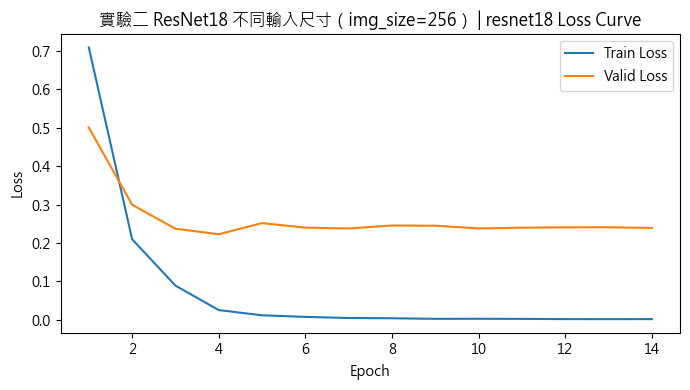

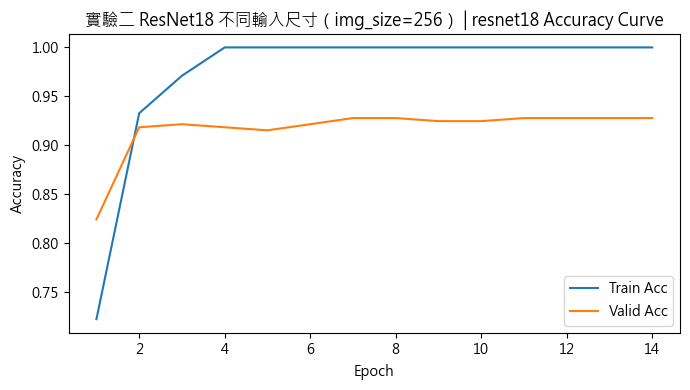

---- classification_report (Test set) ----
              precision    recall  f1-score   support

         amd     0.9423    0.9800    0.9608       100
    cataract     0.9899    0.9800    0.9849       100
    diabetes     0.9355    0.8700    0.9016       100
      normal     0.8942    0.9300    0.9118       100

    accuracy                         0.9400       400
   macro avg     0.9405    0.9400    0.9398       400
weighted avg     0.9405    0.9400    0.9398       400



,class,precision,recall,f1,support
0,amd,0.942308,0.98,0.960784,100
1,cataract,0.989899,0.98,0.984925,100
2,diabetes,0.935484,0.87,0.901554,100
3,normal,0.894231,0.93,0.911765,100


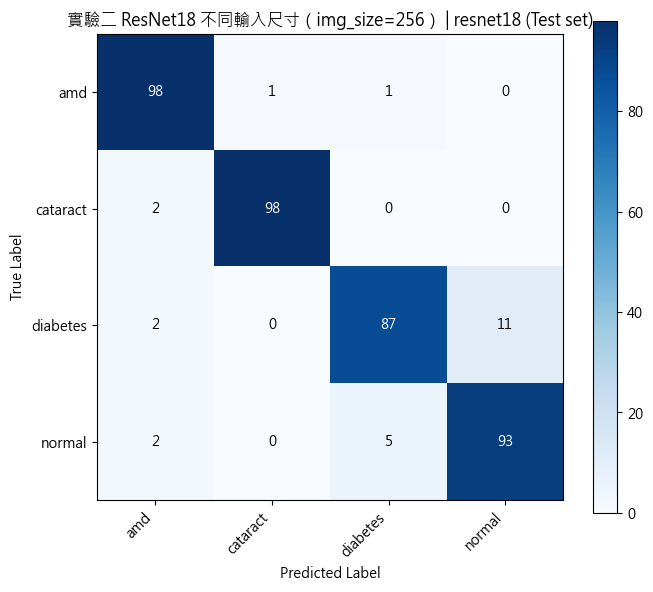

=== 實驗二結果表 ===


,exp_name,model,img_size,augmentation,freeze,acc,precision_macro,recall_macro,f1_macro,epochs_run,train_time_sec
1,實驗二 ResNet18 不同輸入尺寸（img_size=256）,resnet18,256,False,False,0.9400,0.940480,0.9400,0.939757,14,343.739157
0,實驗二 ResNet18 不同輸入尺寸（img_size=128）,resnet18,128,False,False,0.8975,0.904248,0.8975,0.894313,13,288.558940


In [33]:
exp2_summaries = []

for sz in [128, 256]:
    exp2_summaries.append(run_and_report(
        exp_name=f"實驗二 ResNet18 不同輸入尺寸（img_size={sz}）",
        model_name="resnet18",
        img_size=sz,
        use_augmentation=False,   # 控制變因：維持 augmentation
        freeze_backbone=False
    ))

exp2_df = pd.DataFrame(exp2_summaries)
print("=== 實驗二結果表 ===")
display(exp2_df.sort_values(by="acc", ascending=False))




### 18.實驗三：Freeze vs Fine-tune（mobilenetv2；img_size=256；有 augmentation）


實驗：實驗3-1 Freeze backbone（只訓練 fc）
model=resnet18 | img_size=224 | aug=False | freeze=True
[resnet18] Epoch 001/50 | Train Loss 1.3834 Acc 0.3730 | Val Loss 1.3161 Acc 0.4528
[resnet18] Epoch 002/50 | Train Loss 1.3025 Acc 0.3958 | Val Loss 1.2496 Acc 0.4843
[resnet18] Epoch 003/50 | Train Loss 1.2485 Acc 0.4318 | Val Loss 1.1988 Acc 0.5220
[resnet18] Epoch 004/50 | Train Loss 1.1960 Acc 0.4812 | Val Loss 1.1481 Acc 0.5566
[resnet18] Epoch 005/50 | Train Loss 1.1475 Acc 0.5345 | Val Loss 1.0980 Acc 0.5943
[resnet18] Epoch 006/50 | Train Loss 1.1025 Acc 0.5635 | Val Loss 1.0562 Acc 0.6132
[resnet18] Epoch 007/50 | Train Loss 1.0647 Acc 0.6019 | Val Loss 1.0175 Acc 0.6478
[resnet18] Epoch 008/50 | Train Loss 1.0281 Acc 0.6215 | Val Loss 0.9809 Acc 0.6635
[resnet18] Epoch 009/50 | Train Loss 0.9927 Acc 0.6418 | Val Loss 0.9489 Acc 0.6855
[resnet18] Epoch 010/50 | Train Loss 0.9677 Acc 0.6560 | Val Loss 0.9198 Acc 0.6950
[resnet18] Epoch 011/50 | Train Loss 0.9401 Acc 0.6669 | Val Loss 0.891

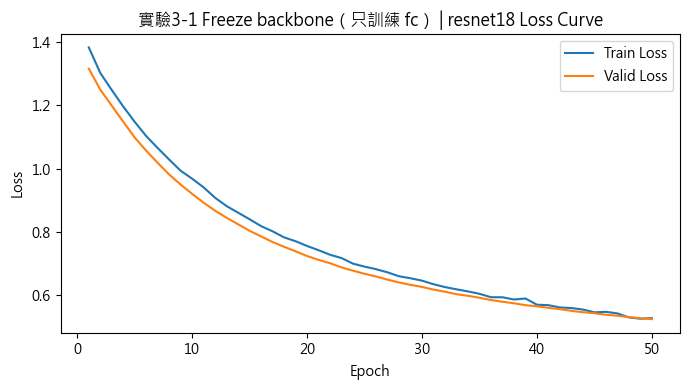

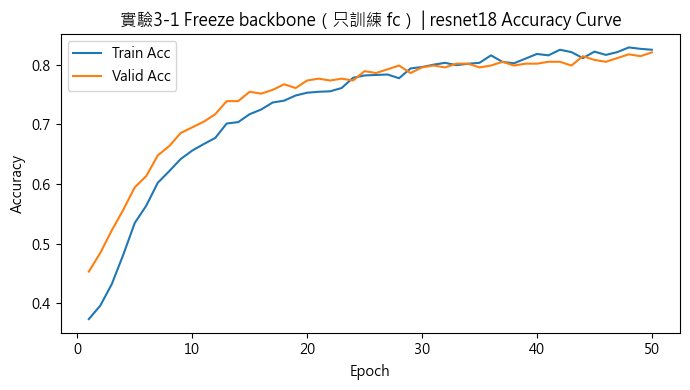

---- classification_report (Test set) ----
              precision    recall  f1-score   support

         amd     0.7826    0.7200    0.7500       100
    cataract     0.9510    0.9700    0.9604       100
    diabetes     0.6739    0.6200    0.6458       100
      normal     0.7895    0.9000    0.8411       100

    accuracy                         0.8025       400
   macro avg     0.7992    0.8025    0.7993       400
weighted avg     0.7992    0.8025    0.7993       400



,class,precision,recall,f1,support
0,amd,0.782609,0.72,0.750000,100
1,cataract,0.950980,0.97,0.960396,100
2,diabetes,0.673913,0.62,0.645833,100
3,normal,0.789474,0.90,0.841121,100


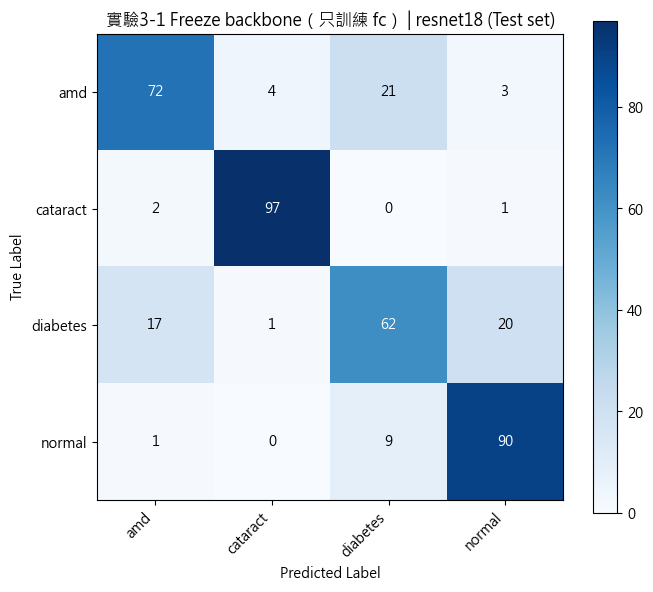

=== 實驗 3 結果表 ===


,exp_name,model,img_size,augmentation,freeze,acc,precision_macro,recall_macro,f1_macro,epochs_run,train_time_sec
0,實驗3-1 Freeze backbone（只訓練 fc）,resnet18,224,False,True,0.8025,0.799244,0.8025,0.799338,50,1163.40493


In [34]:
expA_summaries = []

# Freeze backbone：只訓練 fc
expA_summaries.append(run_and_report(
    exp_name="實驗3-1 Freeze backbone（只訓練 fc）",
    model_name="resnet18",
    img_size=224,
    use_augmentation=False,
    freeze_backbone=True
))

# Fine-tune：全模型訓練
# expA_summaries.append(run_and_report(
#     exp_name="實驗3-2 Fine-tune（全模型訓練）",
#     model_name="resnet18",
#     img_size=224,
#     use_augmentation=False,
#     freeze_backbone=False
# ))

expA_df = pd.DataFrame(expA_summaries)
print("=== 實驗 3 結果表 ===")
display(expA_df.sort_values(by="acc", ascending=False))


### 19. 實驗四：有 / 無 Data Augmentation（mobilenetv2；img_size=224；Fine-tune）


實驗：實驗4-2 有 augmentation（Flip + Rotation）
model=simplecnn | img_size=224 | aug=True | freeze=False
[simplecnn] Epoch 001/50 | Train Loss 1.3510 Acc 0.3096 | Val Loss 1.3783 Acc 0.3396
[simplecnn] Epoch 002/50 | Train Loss 1.2710 Acc 0.4522 | Val Loss 1.3421 Acc 0.3459
[simplecnn] Epoch 003/50 | Train Loss 1.2210 Acc 0.5110 | Val Loss 1.2645 Acc 0.5440
[simplecnn] Epoch 004/50 | Train Loss 1.1791 Acc 0.5345 | Val Loss 1.1796 Acc 0.5629
[simplecnn] Epoch 005/50 | Train Loss 1.1362 Acc 0.5470 | Val Loss 1.1205 Acc 0.5692
[simplecnn] Epoch 006/50 | Train Loss 1.1077 Acc 0.5541 | Val Loss 1.0799 Acc 0.5723
[simplecnn] Epoch 007/50 | Train Loss 1.0705 Acc 0.5752 | Val Loss 1.0469 Acc 0.5881
[simplecnn] Epoch 008/50 | Train Loss 1.0325 Acc 0.5980 | Val Loss 1.0120 Acc 0.6038
[simplecnn] Epoch 009/50 | Train Loss 1.0066 Acc 0.5972 | Val Loss 0.9891 Acc 0.6132
[simplecnn] Epoch 010/50 | Train Loss 0.9713 Acc 0.6144 | Val Loss 0.9679 Acc 0.6132
[simplecnn] Epoch 011/50 | Train Loss 0.9535 Acc 0.6

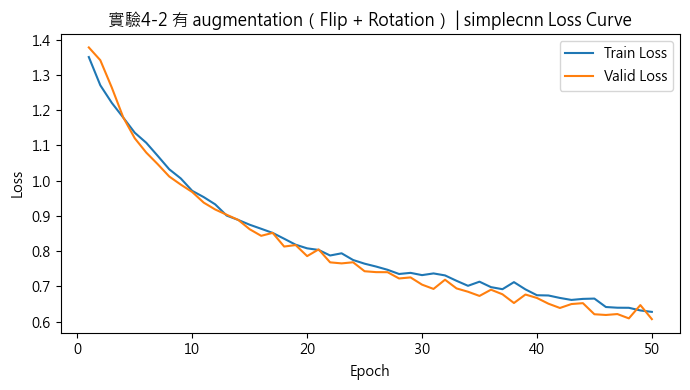

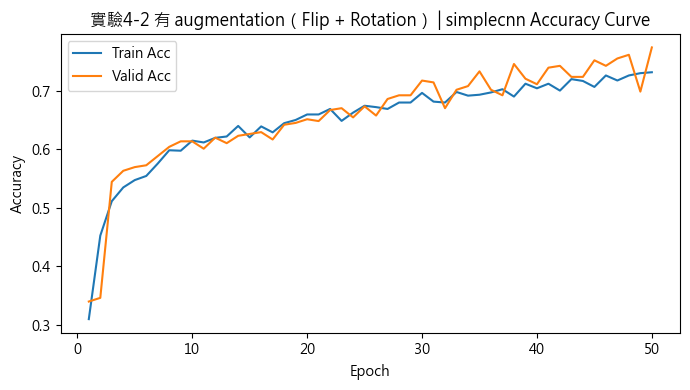

---- classification_report (Test set) ----
              precision    recall  f1-score   support

         amd     0.7083    0.5100    0.5930       100
    cataract     0.9074    0.9800    0.9423       100
    diabetes     0.4956    0.5600    0.5258       100
      normal     0.7196    0.7700    0.7440       100

    accuracy                         0.7050       400
   macro avg     0.7077    0.7050    0.7013       400
weighted avg     0.7077    0.7050    0.7013       400



,class,precision,recall,f1,support
0,amd,0.708333,0.51,0.593023,100
1,cataract,0.907407,0.98,0.942308,100
2,diabetes,0.495575,0.56,0.525822,100
3,normal,0.719626,0.77,0.743961,100


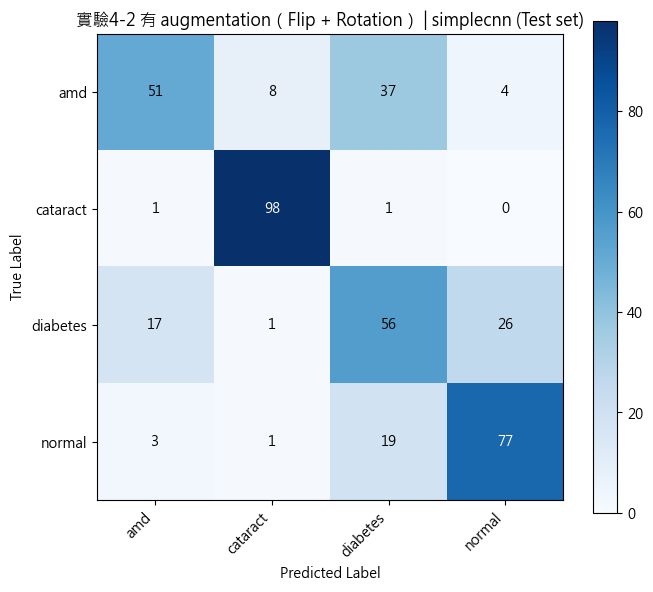

實驗：實驗4-4 有 augmentation（Flip + Rotation）
model=resnet18 | img_size=224 | aug=True | freeze=False
[resnet18] Epoch 001/50 | Train Loss 0.7642 Acc 0.7061 | Val Loss 0.6273 Acc 0.8050
[resnet18] Epoch 002/50 | Train Loss 0.3123 Acc 0.8785 | Val Loss 0.3387 Acc 0.8742
[resnet18] Epoch 003/50 | Train Loss 0.2044 Acc 0.9255 | Val Loss 0.2675 Acc 0.8931
[resnet18] Epoch 004/50 | Train Loss 0.1412 Acc 0.9545 | Val Loss 0.2422 Acc 0.9182
[resnet18] Epoch 005/50 | Train Loss 0.0917 Acc 0.9726 | Val Loss 0.2467 Acc 0.9277
[resnet18] Epoch 006/50 | Train Loss 0.0614 Acc 0.9859 | Val Loss 0.2379 Acc 0.9308
[resnet18] Epoch 007/50 | Train Loss 0.0562 Acc 0.9812 | Val Loss 0.2446 Acc 0.9277
[resnet18] Epoch 008/50 | Train Loss 0.0355 Acc 0.9914 | Val Loss 0.2512 Acc 0.9151
[resnet18] Epoch 009/50 | Train Loss 0.0234 Acc 0.9937 | Val Loss 0.2329 Acc 0.9214
[resnet18] Epoch 010/50 | Train Loss 0.0203 Acc 0.9969 | Val Loss 0.2236 Acc 0.9308
[resnet18] Epoch 011/50 | Train Loss 0.0146 Acc 0.9984 | Val Lo

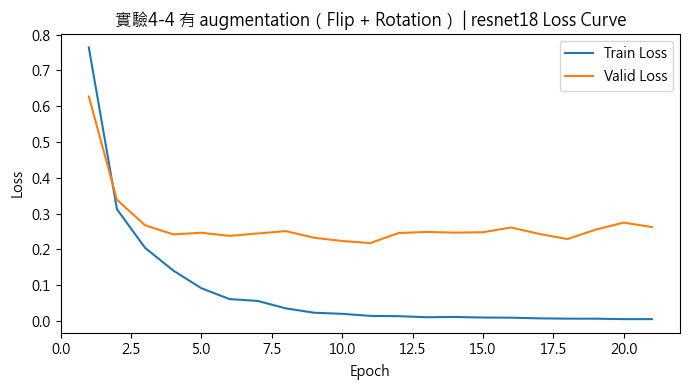

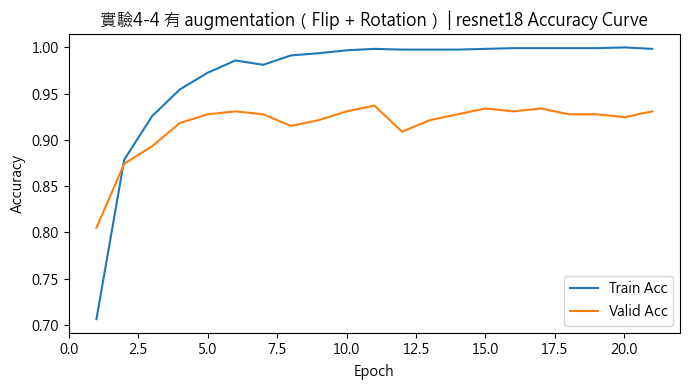

---- classification_report (Test set) ----
              precision    recall  f1-score   support

         amd     0.9429    0.9900    0.9659       100
    cataract     1.0000    0.9800    0.9899       100
    diabetes     0.9485    0.9200    0.9340       100
      normal     0.9600    0.9600    0.9600       100

    accuracy                         0.9625       400
   macro avg     0.9628    0.9625    0.9624       400
weighted avg     0.9628    0.9625    0.9624       400



,class,precision,recall,f1,support
0,amd,0.942857,0.99,0.965854,100
1,cataract,1.000000,0.98,0.989899,100
2,diabetes,0.948454,0.92,0.934010,100
3,normal,0.960000,0.96,0.960000,100


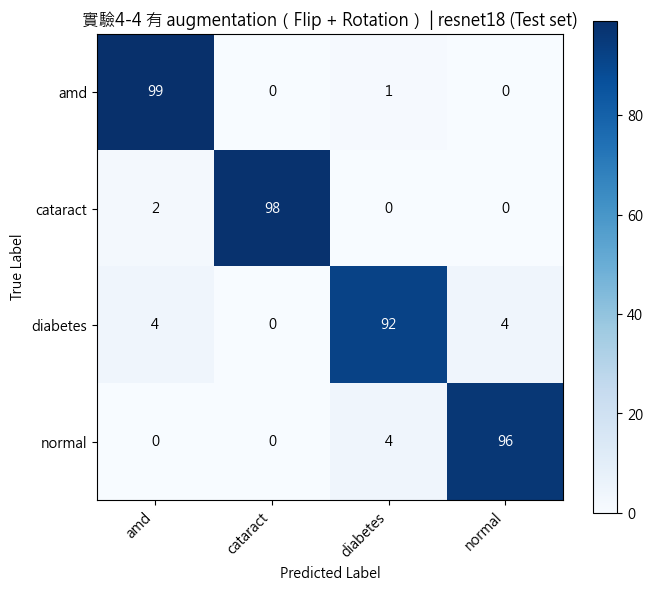

=== 實驗 4 結果表 ===


,exp_name,model,img_size,augmentation,freeze,acc,precision_macro,recall_macro,f1_macro,epochs_run,train_time_sec
1,實驗4-4 有 augmentation（Flip + Rotation）,resnet18,224,True,False,0.9625,0.962828,0.9625,0.962441,21,499.445886
0,實驗4-2 有 augmentation（Flip + Rotation）,simplecnn,224,True,False,0.7050,0.707736,0.7050,0.701278,50,1174.182769


In [35]:
expB_summaries = []

# 無 augmentation

# expB_summaries.append(run_and_report(
#     exp_name="實驗4-1 無 augmentation",
#     model_name="simplecnn",
#     img_size=224,
#     use_augmentation=False,
#     freeze_backbone=False
# ))

# 有 augmentation
expB_summaries.append(run_and_report(
    exp_name="實驗4-2 有 augmentation（Flip + Rotation）",
    model_name="simplecnn",
    img_size=224,
    use_augmentation=True,
    freeze_backbone=False
))

# expB_summaries.append(run_and_report(
#     exp_name="實驗4-3 有 augmentation",
#     model_name="resnet18",
#     img_size=224,
#     use_augmentation=False,
#     freeze_backbone=False
# ))

expB_summaries.append(run_and_report(
    exp_name="實驗4-4 有 augmentation（Flip + Rotation）",
    model_name="resnet18",
    img_size=224,
    use_augmentation=True,
    freeze_backbone=False
))



expB_df = pd.DataFrame(expB_summaries)
print("=== 實驗 4 結果表 ===")
display(expB_df.sort_values(by="acc", ascending=False))


### 20. 結果表格彙整 + 中文結論（含 overfitting 討論）


In [36]:
all_results = pd.concat([exp1_df, exp2_df, expA_df, expB_df], axis=0, ignore_index=True)
print("=== 全部實驗彙整表（依 acc 排序）===")
display(all_results.sort_values(by="acc", ascending=False))

print("\n=== 中文結論（可直接寫進報告）===\n")

# 依結果找出最高 acc 的設定
best_row = all_results.sort_values(by="acc", ascending=False).iloc[0].to_dict()

print("1) 整體最佳設定：")
print(f"   - 實驗名稱：{best_row['exp_name']}")
print(f"   - 模型：{best_row['model']}")
print(f"   - img_size：{best_row['img_size']}")
print(f"   - augmentation：{best_row['augmentation']}")
print(f"   - freeze：{best_row['freeze']}")
print(f"   - Validation Accuracy：{best_row['acc']:.4f}")
print(f"   - 訓練時間（秒）：{best_row['train_time_sec']:.2f}")

=== 全部實驗彙整表（依 acc 排序）===


,exp_name,model,img_size,augmentation,freeze,acc,precision_macro,recall_macro,f1_macro,epochs_run,train_time_sec
6,實驗4-4 有 augmentation（Flip + Rotation）,resnet18,224,True,False,0.9625,0.962828,0.9625,0.962441,21,499.445886
1,實驗一-2 不同模型比較,resnet18,224,False,False,0.9500,0.950123,0.9500,0.949756,17,402.942512
3,實驗二 ResNet18 不同輸入尺寸（img_size=256）,resnet18,256,False,False,0.9400,0.940480,0.9400,0.939757,14,343.739157
2,實驗二 ResNet18 不同輸入尺寸（img_size=128）,resnet18,128,False,False,0.8975,0.904248,0.8975,0.894313,13,288.558940
4,實驗3-1 Freeze backbone（只訓練 fc）,resnet18,224,False,True,0.8025,0.799244,0.8025,0.799338,50,1163.404930
0,實驗一-1 不同模型比較,simplecnn,224,False,False,0.7250,0.723809,0.7250,0.720892,50,1183.177518
5,實驗4-2 有 augmentation（Flip + Rotation）,simplecnn,224,True,False,0.7050,0.707736,0.7050,0.701278,50,1174.182769



=== 中文結論（可直接寫進報告）===

1) 整體最佳設定：
   - 實驗名稱：實驗4-4 有 augmentation（Flip + Rotation）
   - 模型：resnet18
   - img_size：224
   - augmentation：True
   - freeze：False
   - Validation Accuracy：0.9625
   - 訓練時間（秒）：499.45
